# Characterize Brain & Blood cell type-specific unmethylated markers
How many CpGs? \
How long? \
This will determine `callDMR()` settings

##### Modules

In [2]:
import os
import pandas as pd
import glob
import numpy as np
from typing import Optional, Mapping
from pybedtools import BedTool

import seaborn as sb
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors

##### Fonts & Colors

In [3]:
# font style
locations = ['/home/eger/software/fonts']
font_files = font_manager.findSystemFonts(fontpaths = locations)
for file in font_files:
    font_manager.fontManager.addfont(file)
plt.rcParams['font.family'] = 'Aptos'

# fig size
plt.rcParams['figure.figsize'] = (15, 10)

# font size
title_size = 16
label_size = 14
tick_size = 12

##### Inputs

In [4]:
bb_cts = [
 'Blood-B',
 'Blood-Granul',
 'Blood-Mono+Macro',
 'Blood-NK',
 'Blood-T',
 'Neuron',
 'Oligodend']

# includes the supergroup
bb_groups = [
 'Blood-B',
 'Blood-Granul',
 'Blood-Mono+Macro',
 'Blood-NK',
 'Blood-T',
 'Neuron',
 'Neuron:Oligodend',
 'Oligodend']    

In [5]:
REF_DIR = '/home/eger/software/UXM_deconv/supplemental'

OUTDIR = '/scratch/eger/projects/MethSmoothEval/tissues/DM_analysis/UXM'

In [6]:
# from Loyfer 2023
fname0 = os.path.join(REF_DIR, 'Supplementary_Tables_1–17.xlsx') 

### Top 25 unmethylated markers

In [7]:
# from github
fname1 = os.path.join(REF_DIR, 'Atlas.U25.l4.hg19.full.tsv')
fname2 = os.path.join(REF_DIR, 'Atlas.U25.l4.hg38.full.tsv')

# from UCSC liftover
bed1 = os.path.join(REF_DIR, 'Atlas.U25.Brain_Blood_lifted_to_hg38.bed')

# from the supplemental
df0 = pd.read_excel(fname0, sheet_name='Table S4A', skiprows=2)

df1 = pd.read_csv(fname1, sep='\t')
df2 = pd.read_csv(fname2, sep='\t')
df_b1 = pd.read_csv(bed1, sep='\t', header=None, 
                    usecols=[0, 1, 2, 3], names=['chr', 'start', 'end', 'position'])

In [8]:
df0 = df0[df0['Type'].isin(bb_groups)]
df0['Number of CpGs'] = df0['Number of CpGs'].apply(lambda x: int(x.split('CpGs')[0]))
df0['Length'] = df0['Length'].apply(lambda x: int(x.split('bp')[0]))

In [9]:
x_var = 'Number of CpGs'
pd.DataFrame(df0[x_var].describe())

,Number of CpGs
count,200.000000
mean,9.980000
std,5.970581
min,5.000000
25%,6.000000
50%,8.000000
75%,12.000000
max,54.000000


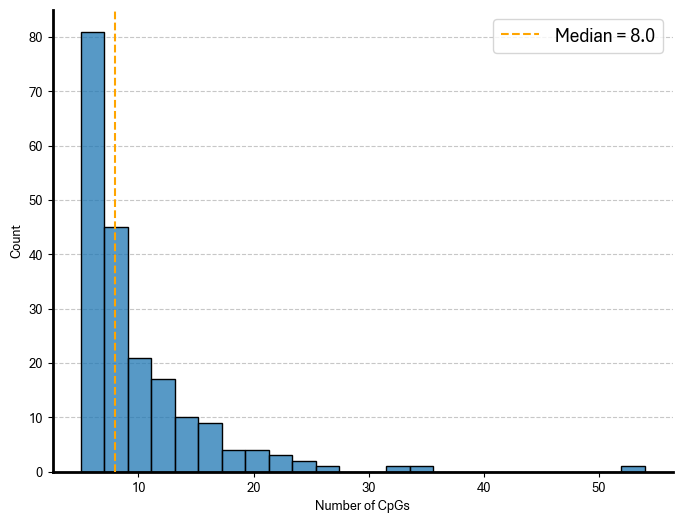

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

sb.histplot(data=df0, x=x_var, zorder=2)

# median line
median = df0[x_var].median()
ax.axvline(median, color='orange', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median}')

ax.legend(fontsize=label_size)
plt.show()

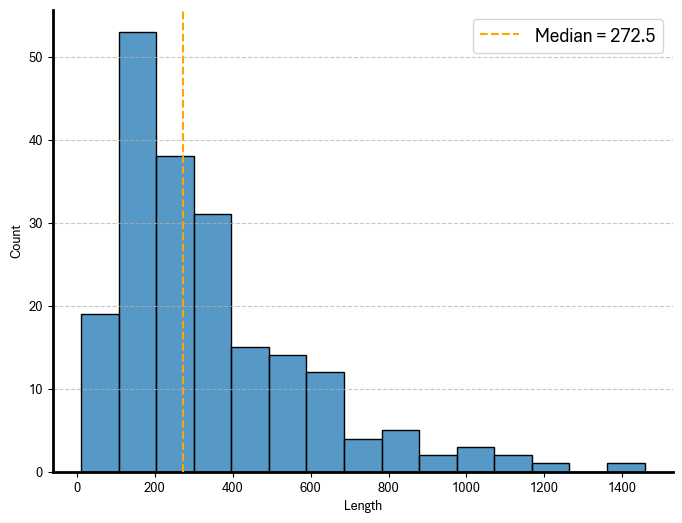

In [11]:
x_var = 'Length'
fig, ax = plt.subplots(figsize=(8, 6))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

sb.histplot(data=df0, x=x_var)

# median line
median = df0[x_var].median()
ax.axvline(median, color='orange', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median}')

ax.legend(fontsize=label_size)
plt.show()

#### Make .tsv for DMR overlap search
One region did not liftover properly because it is Split in hg38:
chr9:43425711-43426476

In [90]:
df_b1['start_hg19'] = df_b1['position'].apply(lambda x: int(x.split(':')[-1].split('-')[0]) - 1)

In [91]:
# drop the region that didn't lift
df_b1 = df_b1[df_b1['start_hg19'] != 43425711]

In [92]:
df_b1.index = df_b1['start_hg19']
df0.index = df0['start']

df_b1 = df_b1[['chr', 'start', 'end']]

In [93]:
# add columns
df_b1.loc[df_b1.index, 'best_group'] = df0.loc[df_b1.index, 'Type']
df_b1['best_dir'] = 'hypo'
df_b1['location'] = df_b1['chr']+':'+df_b1['start'].astype(str)+'-'+df_b1['end'].astype(str)
df_b1.loc[df_b1.index, 'n_cpgs'] = df0.loc[df_b1.index, 'Number of CpGs']

In [97]:
df_b1['n_cpgs'] = df_b1['n_cpgs'].astype(int)

In [98]:
out1 = os.path.join(REF_DIR, 'Atlas.U25.Brain_Blood_lifted_to_hg38.tsv')
df_b1.to_csv(out1, sep='\t', index=False)

In [99]:
print('Total CpGs in hg19 atlas regions:', df0[df0['start'] != 43425711]['Number of CpGs'].sum())

Total CpGs in hg19 atlas regions: 1983


In [100]:
df_b1

,chr,start,end,best_group,best_dir,location,n_cpgs
start_hg19,,,,,,,
74419888,chr17,76423806,76424009,Blood-B,hypo,chr17:76423806-76424009,8
1648937,chr19,1648938,1648992,Blood-B,hypo,chr19:1648938-1648992,6
16373028,chr20,16392383,16392649,Blood-B,hypo,chr20:16392383-16392649,8
91138717,chr15,90595485,90595714,Blood-B,hypo,chr15:90595485-90595714,9
16554452,chr19,16443641,16443937,Blood-B,hypo,chr19:16443641-16443937,10
...,...,...,...,...,...,...,...
183517689,chr3,183799901,183800128,Oligodend,hypo,chr3:183799901-183800128,13
75149176,chr14,74682473,74682865,Oligodend,hypo,chr14:74682473-74682865,8
159776363,chr4,158855211,158855402,Oligodend,hypo,chr4:158855211-158855402,5


### Top 250 unmethylated markers

In [33]:
# from github
fname1 = os.path.join(REF_DIR, 'Atlas.U250.l4.hg19.full.tsv')
fname2 = os.path.join(REF_DIR, 'Atlas.U250.l4.hg38.full.tsv')

# from UCSC liftover
bed1 = os.path.join(REF_DIR, 'Atlas.U250.Brain_Blood_lifted_to_hg38.bed')

# from the supplemental
df0 = pd.read_excel(fname0, sheet_name='Table S4B', skiprows=2)

df1 = pd.read_csv(fname1, sep='\t')
df2 = pd.read_csv(fname2, sep='\t')
df_b1 = pd.read_csv(bed1, sep='\t', header=None, 
                    usecols=[0, 1, 2, 3], names=['chr', 'start', 'end', 'position'])

In [42]:
# only brain blood cell types
df0 = df0[df0['Type'].isin(bb_groups)]

# remove duplicated positions for Neuron and Neuron:Oligodend
df0 = df0.sort_values(['position', 'Type'])
df0 = df0.drop_duplicates(subset=['position'])

In [43]:
df0.shape

(1978, 16)

In [45]:
# get characteristics
df0['Number of CpGs'] = df0['Number of CpGs'].apply(lambda x: int(x.split('CpGs')[0]))
df0['Length'] = df0['Length'].apply(lambda x: int(x.split('bp')[0]))

In [46]:
x_var = 'Number of CpGs'
pd.DataFrame(df0[x_var].describe())

,Number of CpGs
count,1978.000000
mean,8.615774
std,4.347220
min,5.000000
25%,6.000000
50%,7.000000
75%,10.000000
max,54.000000


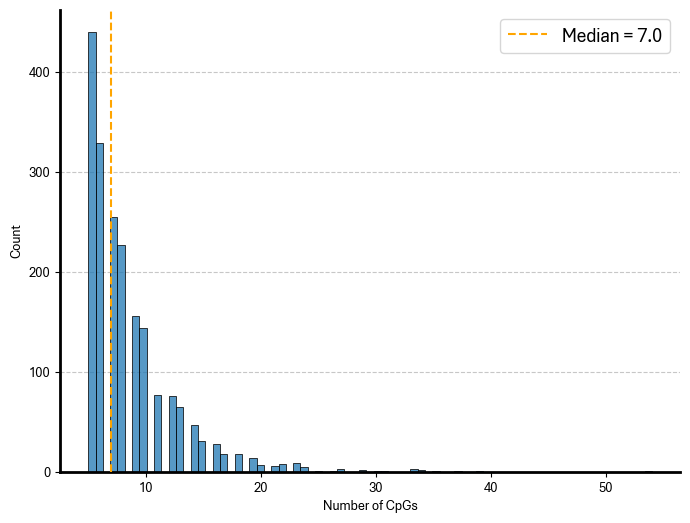

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

sb.histplot(data=df0, x=x_var, zorder=2)

# median line
median = df0[x_var].median()
ax.axvline(median, color='orange', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median}')

ax.legend(fontsize=label_size)
plt.show()

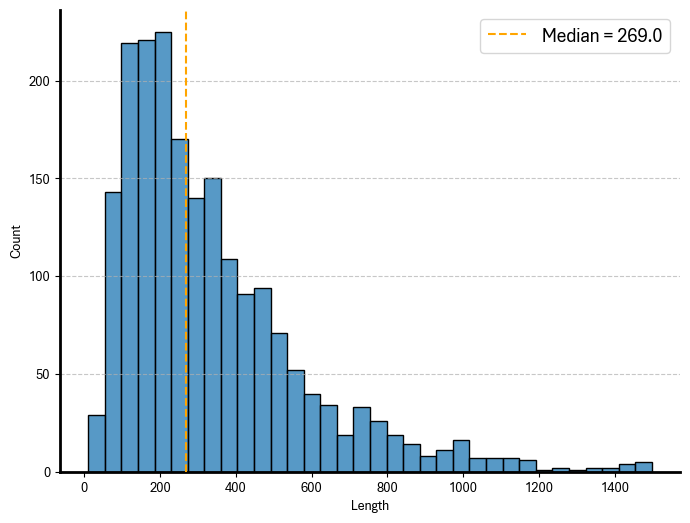

In [48]:
x_var = 'Length'
fig, ax = plt.subplots(figsize=(8, 6))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

sb.histplot(data=df0, x=x_var)

# median line
median = df0[x_var].median()
ax.axvline(median, color='orange', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median}')

ax.legend(fontsize=label_size)
plt.show()

#### Make .tsv for DMR overlap search
One region did not liftover properly because it is Split in hg38:
chr9:43425711-43426476

In [49]:
# drop duplicates
df_b1 = df_b1.drop_duplicates()

# get start position
df_b1['start_hg19'] = df_b1['position'].apply(lambda x: int(x.split(':')[-1].split('-')[0]) - 1)

In [50]:
# set indexes
df_b1.index = df_b1['start_hg19']
df0.index = df0['start']

df_b1 = df_b1[['chr', 'start', 'end']]

In [51]:
# add columns
df_b1.loc[df_b1.index, 'best_group'] = df0.loc[df_b1.index, 'Type']
df_b1['best_dir'] = 'hypo'
df_b1['location'] = df_b1['chr']+':'+df_b1['start'].astype(str)+'-'+df_b1['end'].astype(str)
df_b1.loc[df_b1.index, 'n_cpgs'] = df0.loc[df_b1.index, 'Number of CpGs']
df_b1['n_cpgs'] = df_b1['n_cpgs'].astype(int)

In [52]:
out1 = os.path.join(REF_DIR, 'Atlas.U250.Brain_Blood_lifted_to_hg38.tsv')
df_b1.to_csv(out1, sep='\t', index=False)

In [53]:
print('Total CpGs in hg19 atlas regions:', df_b1['n_cpgs'].sum())

Total CpGs in hg19 atlas regions: 17029


In [54]:
df_b1

,chr,start,end,best_group,best_dir,location,n_cpgs
start_hg19,,,,,,,
74419888,chr17,76423806,76424009,Blood-B,hypo,chr17:76423806-76424009,8
1648937,chr19,1648938,1648992,Blood-B,hypo,chr19:1648938-1648992,6
16373028,chr20,16392383,16392649,Blood-B,hypo,chr20:16392383-16392649,8
50736822,chr15,50444625,50445010,Blood-B,hypo,chr15:50444625-50445010,7
107096723,chr6,106648848,106649202,Blood-B,hypo,chr6:106648848-106649202,7
...,...,...,...,...,...,...,...
102881560,chr14,102415223,102415951,Oligodend,hypo,chr14:102415223-102415951,19
3751216,chr1,3834652,3835070,Oligodend,hypo,chr1:3834652-3835070,11
134549977,chr10,132736473,132736657,Oligodend,hypo,chr10:132736473-132736657,12
